![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World! 

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [185]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", parse_dates=["Date Rptd", "DATE OCC"], dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,221412410,2022-06-15,2020-11-12,1700,Pacific,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),0,NaN,NaN,NaN,Invest Cont,13600 MARINA POINT DR
1,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
2,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
3,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
4,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV


In [186]:
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247988 entries, 0 to 247987
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   DR_NO         247988 non-null  int64         
 1   Date Rptd     247988 non-null  datetime64[ns]
 2   DATE OCC      247988 non-null  datetime64[ns]
 3   TIME OCC      247988 non-null  object        
 4   AREA NAME     247988 non-null  object        
 5   Crm Cd Desc   247988 non-null  object        
 6   Vict Age      247988 non-null  int64         
 7   Vict Sex      215740 non-null  object        
 8   Vict Descent  215739 non-null  object        
 9   Weapon Desc   80087 non-null   object        
 10  Status Desc   247988 non-null  object        
 11  LOCATION      247988 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(8)
memory usage: 22.7+ MB


In [187]:
crimes.describe()

,DR_NO,Vict Age
count,2.479880e+05,247988.000000
mean,2.256571e+08,29.954764
std,5.042345e+06,21.901016
min,2.203000e+03,-2.000000
25%,2.210130e+08,0.000000
50%,2.220131e+08,31.000000
75%,2.310058e+08,45.000000
max,2.399165e+08,99.000000


In [188]:
# check for null values
crimes.isna().sum()

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex         32248
Vict Descent     32249
Weapon Desc     167901
Status Desc          0
LOCATION             0
dtype: int64

In [189]:
# Which hour has the highest frequency of crimes?
freq_crimes = crimes['TIME OCC'].value_counts()
freq_crimes

1200    8333
1800    6183
1700    5824
2000    5606
1900    5250
        ... 
0756       5
2254       5
2259       5
0542       5
0531       3
Name: TIME OCC, Length: 1439, dtype: int64

In [190]:
peak_crime_hour = int(freq_crimes.index[0][:2])
peak_crime_hour

12

In [191]:
# Which area has the largest frequency of night crimes (crimes committed between 10pm and 3:59am)?
crimes['TIME OCC'].astype(int).max()

2359

In [192]:
crimes['TIME OCC'].astype(int).min()

1

In [193]:
crimes_10pm_4am = crimes[(crimes['TIME OCC'].astype(int) > 2159) | (crimes['TIME OCC'].astype(int) < 400)]

crimes_10pm_4am

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
9,231207476,2023-02-27,2020-08-15,0001,77th Street,BURGLARY,72,M,B,NaN,Invest Cont,8800 HAAS AV
12,221711184,2022-06-15,2020-05-15,0155,Devonshire,THEFT OF IDENTITY,27,M,B,NaN,Invest Cont,8300 WHITE OAK AV
36,221314362,2022-07-11,2020-04-07,0001,Newton,THEFT OF IDENTITY,53,F,H,NaN,Invest Cont,1600 E OLYMPIC BL
39,231307252,2023-03-03,2020-07-05,2305,Newton,THEFT OF IDENTITY,22,F,B,NaN,Invest Cont,6600 S BROADWAY
42,221614254,2022-11-13,2020-01-01,0001,Foothill,THEFT OF IDENTITY,22,F,H,NaN,Invest Cont,10200 TELFAIR AV
...,...,...,...,...,...,...,...,...,...,...,...,...
247964,231212224,2023-05-17,2023-05-17,2300,77th Street,VIOLATION OF RESTRAINING ORDER,35,F,H,NaN,Invest Cont,8200 S MAIN ST
247970,231300825,2023-06-07,2023-06-07,2203,Newton,BATTERY - SIMPLE ASSAULT,45,F,B,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,2300 WALL ST
247971,230908346,2023-04-19,2023-04-18,2243,Van Nuys,THEFT OF IDENTITY,34,F,B,NaN,Invest Cont,4800 COLDWATER CANYON AV
247972,230406516,2023-03-19,2023-03-19,0122,Hollenbeck,VEHICLE - STOLEN,0,NaN,NaN,NaN,Invest Cont,3200 GARNET ST


In [194]:
crimes_10pm_4am_area = crimes_10pm_4am['AREA NAME'].value_counts()
crimes_10pm_4am_area

Central        4091
77th Street    3362
Hollywood      3299
Newton         2927
Southeast      2884
Olympic        2851
Southwest      2787
Pacific        2773
N Hollywood    2597
Rampart        2480
Northeast      2342
Wilshire       2243
Harbor         2128
West Valley    2106
Van Nuys       2029
Mission        1907
Devonshire     1900
Hollenbeck     1892
West LA        1864
Topanga        1743
Foothill       1707
Name: AREA NAME, dtype: int64

Text(0, 0.5, '# OF CRIMES')

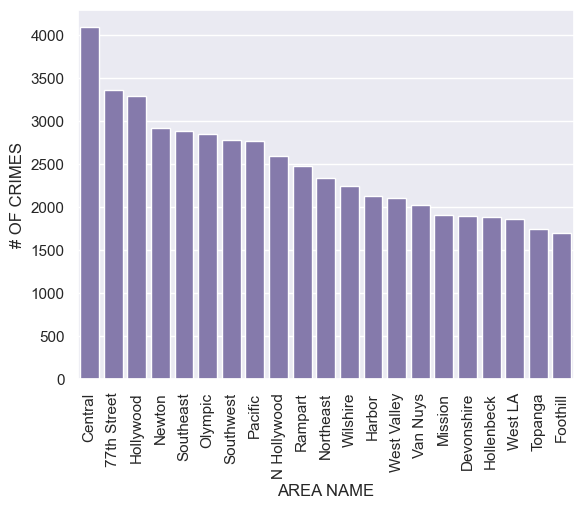

In [195]:
sns.set()
sns.barplot(crimes_10pm_4am_area, color='m')
plt.xticks(rotation=90)
plt.xlabel('AREA NAME')
plt.ylabel('# OF CRIMES')

In [196]:
peak_night_crime_location = crimes_10pm_4am_area.index[0]
print(f"The area with the largest volume of night crime is {peak_night_crime_location}")

The area with the largest volume of night crime is Central


In [197]:
'''Identify the number of crimes committed against victims by age group'''

# Using cut() - create category ranges and names
ranges = [0, 17, 25, 34, 44, 54, 64, np.inf] # age 0 means null value
age_group = ['0-17', '18-25', '26-34', '35-44', '45-54', '55-64', '65+']
# Create age group column
crimes['age_group'] = pd.cut(crimes['Vict Age'], bins=ranges, labels=age_group)

crimes[['Vict Age', 'age_group']]

,Vict Age,age_group
0,0,NaN
1,27,26-34
2,60,55-64
3,28,26-34
4,37,35-44
...,...,...
247983,25,18-25
247984,23,18-25
247985,25,18-25
247986,29,26-34


In [198]:
victim_ages = crimes['age_group'].value_counts()
type(victim_ages)

pandas.core.series.Series

In [199]:
victim_ages

26-34    47470
35-44    42157
45-54    28353
18-25    28291
55-64    20169
65+      14747
0-17      4528
Name: age_group, dtype: int64

Text(0, 0.5, 'Amount')

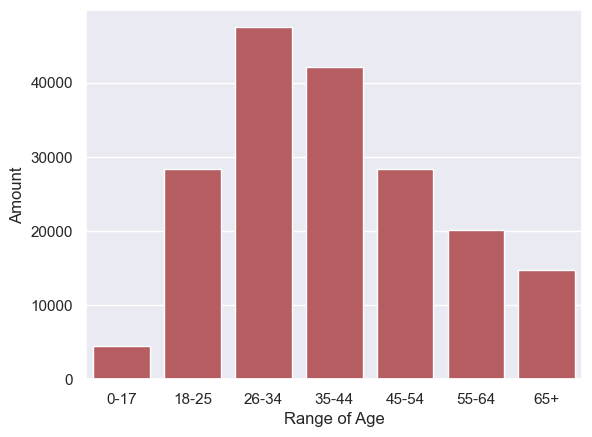

In [200]:
sns.set()
sns.barplot(victim_ages, color='r')
plt.xlabel('Range of Age')
plt.ylabel('Amount')